# Dynamic Pricing TS Notebook

* Imports
* Demand and TS Parameters
* Economics - Price, Demand, Revenue, Profit
* TS Model
* TS Iteration
* Save Rusults


# Imports

In [1]:
# Python version
!python --version

Python 3.12.7


In [4]:
# General Imports
import sys
import numpy as np
import pandas as pd
import beautifulplots as bp
import matplotlib.pyplot as plt

import pymc as pm
from math import ceil

import random

# Set Seed
np.random.seed(42) # keeps stats numbers repeatable ... convenientfor initial development

from pathlib import Path

sys.path.append(str(Path("..") / "py_modules"))

# Demand and TS Parameters

In [5]:
example_case = "case2"

variable_cost = 1.2
fixed_cost = 6
v_true = 1.8
a_true = 4000

# set demand variables
# also set some simulation variables ... this is a convenient place
#   to keep from repeating code logic

# low variability
if example_case == "case1": # hard example 
    CV_true = .05
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6 # w sigma_log .04 can be further away from optimal price

elif example_case == "case2": # medium difficutlty
    CV_true = .20
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6  # w sigma_log .15 need to be closer to target
    Nrounds = 100

elif example_case == "case3" : # hard
    CV_true = .30
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6

else:   # default to None
    v_true = None
    a_true = None
    sigma_log_true = None
    variable_cost = None
    fixed_cost = None
    p1 = None

    
#m_log = a_true + p1 ** (-v_true) # logD before additive noise
#d1m =  a_true * p1 ** (-v_true) * np.exp(sigma_log_true**2 / 2) # E[D] at p1

# p1 = 3.6 corresponds to an initial guess of v = 1.5 with variable cost of 1.2

def print_demand_vars():
    print("DEMAND VARIABLES")
    print(f'  v_true = {v_true}')
    print(f'  a_true = {a_true}')
    print(f'  CV_true = {CV_true}')
    print(f'  sigma_log_true = {round(sigma_log_true,2)}')
    print(f'  variable_cost = {variable_cost}')
    print(f'  fixed_cost = {fixed_cost}')
    print(f"  p1 (initial price point) = {p1}")
    #print(f"  d1m = (E[D] at p1) = {round(d1m,2)}")
    
print_demand_vars()


DEMAND VARIABLES
  v_true = 1.8
  a_true = 4000
  CV_true = 0.2
  sigma_log_true = 0.2
  variable_cost = 1.2
  fixed_cost = 6
  p1 (initial price point) = 3.6


#### Derived Parameters

In [6]:
# derived parameters

if v_true <= 1:
    p_opt  = variable_cost 
else:
    p_opt = (v_true / (v_true - 1)) * variable_cost
    
D_opt = a_true * p_opt **(-v_true)
Profit_opt = p_opt * D_opt - variable_cost * D_opt - fixed_cost  
D_true_p1= a_true * p1 **(-v_true)
Profit_p1 = p1* D_true_p1 - variable_cost * D_true_p1 - fixed_cost


# noise inflation term
e_term = np.exp(sigma_log_true**2 / 2)
D_opt_mean = D_opt * e_term
profit_p1_mean = p1 * D_true_p1 * e_term - variable_cost * D_true_p1 * e_term - fixed_cost
profit_popt_mean = p_opt * D_opt * e_term - variable_cost * D_opt * e_term - fixed_cost
    
print("price optimum")
print(f'  p_opt = {round(p_opt,2)}, ... optimal price given true params')
print("median")    
print(f'  D_opt = {round(D_opt,2)}, ... optimal demand given true params')
print(f'  Profit_opt = {round(Profit_opt,2)}, ... optimal profit given true params')
print(f'  D_true_p1 = {round(D_true_p1,2)}, ... demand true Mean at p1 = {round(p1,2)}')
print(f'  Profit_p1 = {Profit_p1}')

print("mean")
print(f'  D_opt_mean = {round(D_opt_mean,2)}, ... optimal demand mean given true params')
print(f'  Profit_p1_mean = {round(profit_p1_mean,2)}, ... mean profit at p1 = {round(p1,2)}')
print(f'  Profit_popt_mean = {round(profit_popt_mean,2)}, ... mean profit at p_opt = {round(p_opt,2)}')



price optimum
  p_opt = 2.7, ... optimal price given true params
median
  D_opt = 669.28, ... optimal demand given true params
  Profit_opt = 997.91, ... optimal profit given true params
  D_true_p1 = 398.76, ... demand true Mean at p1 = 3.6
  Profit_p1 = 951.0325999671358
mean
  D_opt_mean = 682.53, ... optimal demand mean given true params
  Profit_p1_mean = 969.99, ... mean profit at p1 = 3.6
  Profit_popt_mean = 1017.8, ... mean profit at p_opt = 2.7


####  Model Input Parameters

In [7]:
# Prior a Parameters
  #   - important, can get large and blow things out
  #   - careful with  CV = sigma_a / mu_a
  #   - CV = 0.2 tight good (sigma_a = 600/3000), 
  #   - CV = 0.4 = reasonable, well behaved posterior

CV_a = 0.05 # = sigma_linear / mu_linear
m_a_linear  = a_true -100
sigma_a_linear =  CV_a * m_a_linear
sigma_a = np.sqrt(np.log(1 + CV_a**2))
m_a = round(np.log(m_a_linear) - 0.5 * sigma_a**2, 2)

# Prior v Parameters
   #  - ecommerce demand [1.4 , 1.8]
   #  -  sigma_v .3 to .4 good
   #  - sigma_v  0.5 noisy demand ... borderline large
   #  - values near 1 can cause large price swings
   #  - truncated notrmal lower_v hyper ... prevent gettng too close to 1
   # parameters ... m_vtn, signma_v
   
m_v, sigma_v = 1.5, 0.4    #  hyperparameters for prior v
lower_v = 1.1
upper_v = np.inf

if example_case == "case1":
    CV = .06 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
elif example_case == "case2":
    CV = .18 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
elif example_case == "case3":
    CV = .4 # prior hyperparameter
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
else:
    CV = None
    sigma_log = None

price_min = 2
price_max = 4.0

def print_hyper_params():
    hyper_param_str = f"""
Model Input Parameters
  CV_a = {CV_a}, m_a_linear = {m_a_linear}, sigma_a_linear = {sigma_a_linear}
     m_v = {m_v}, sigma_a = {round(sigma_a,4)}
  m_v {m_v}, sigma_v = {sigma_v}, lower_v = {lower_v}
  CV = {CV}, sigma_log = {round(sigma_log,4)}
  price_min = {price_min}
  price_max = {price_max} """
    
    print(hyper_param_str)


print_hyper_params()


Model Input Parameters
  CV_a = 0.05, m_a_linear = 3900, sigma_a_linear = 195.0
     m_v = 1.5, sigma_a = 0.05
  m_v 1.5, sigma_v = 0.4, lower_v = 1.1
  CV = 0.18, sigma_log = 0.1786
  price_min = 2
  price_max = 4.0 


# TS Model

In [9]:
from PymcTsModel import PymcTsModel

# TS Iteration

In [10]:
from  utils_probability import demand_sample

In [11]:
# LOOP PARAMETERS
_simulate = True # default false ... this will take long

##### --- SIM PARAMETERS ---- ##### 
# price control ... if false, no limit on price channge tm.price_max_profit_sample() method
limit_price_change = True

# random local or max local
max_local_price_change_tf = True

fix_sigma_log = True # keep noise variance fixed.
if fix_sigma_log:
    fixed_sigma_log = sigma_log
else:
    fixed_sigma_log_fixed = None


a_fixed = False
if a_fixed==True:
    #m_a_linear_fixed = a_true # convergence test with a_true
    m_a_linear_fixed = m_a_linear

else:
    m_a_linear_fixed = None

##### ------ New Offered Price from Samples ------- ######
# - how much to deviate around the local price anchor
repeat_deviation_1 = 0
repeat_deviation_2 = 0

##### ----- initial prices -----########

# note CV_mean = CV / sqrt(n) ... n = (CV / CV_target)**2
#CV_target = .1 # moderately stable early learning
initial_prices =[p1]

##### -------- Case Specific  Variables ------ ######
        
# example cases and variables
if example_case == "case1": # hard example 
    Nrounds = 50
    N_price_repeat = 2 # effective repeat sample price n-1
    initial_prices = [p1]
    max_price_change_1 = 1 # 10%
    max_price_change_2 = 0.025 # 10%
    K1 = 1
    K2 = 3
    Nk = 75
elif example_case == "case2": # medium difficutlty
    N_price_repeat = 3 # effective repeat sample price n-1
    Nrounds = 30
    initial_prices = [p1]
    initial_prices = [3.6, 2.3]
    max_price_change_1 = 1 # 100%
    max_price_change_2 = 0.05 # 5%
    K1 = 1
    K2 = 1
    Nk = 15
    price_anchor_1 = False
    price_anchor_2 = True
elif example_case == "case3" : # hard
    N_price_repeat = 5 #repeat price
    Nrounds = 150
    initial_prices = [3.3, 3.0, 2.7, 2.4, 2.1]
    K1 = 3
    K2 = 3
    Nk = 25

else:   # default to None
    Nrounds = 10
    K1 = 1
    K2 = 2
    Nk = 10
    Nth_max_local = 3 # Nth time pick random price ... N large effectively turns off
    
#local_price_percent = 0.25
verbose = False

In [12]:
# PRINT PARAMETERS
print(f'example_case = {example_case}')
print()
print_demand_vars() # Demand Variables
print()
print_hyper_params() # Hyper Parameters

variable_defs = """
SIM VARIABLES
"""

print()
print(variable_defs)
#initial_prices = [_p for _p in initial_prices for _ in range(n_initial_prices)]    

print(f'initial_prices = {initial_prices}')
### Initialize Variables

print(f'  fix_sigma_log = {fix_sigma_log}')
if fix_sigma_log:
    print(f'    sigma_log_fixed = {round(fixed_sigma_log,4)}')
    
print(f'  a_fixed = {a_fixed}')
if a_fixed:
    print(f'    m_a_linear_fixed = {m_a_linear_fixed}')
    
print(f'  Nrounds = {Nrounds}, the total number of iteration steps')
print(f'  Nk = {Nk}, Nk : i < Nk _1 variables, i >= Nk   _2 variables')
print(f'  K1 = {K1}, K1 samples for i < Nk')
print(f'  K2 = {K2}, K2 samples for i >= Nk')
print(f'  N_price_repeat = {N_price_repeat}, repeate the offered price N times')
print(f'  initial_prices = {initial_prices}')
print(f'  max_local_price_change_1 = {max_price_change_1}')
if max_local_price_change_tf:
    print(f'  price_anchor_1 = {price_anchor_1}')
    print(f'  price_anchor_2 = {price_anchor_2}')
print(f'  limit_price_change = {limit_price_change}, True/False. If True then limit i step to step price change')
if limit_price_change:
    print(f'    max_price_change_1 = {max_price_change_1},  max_price_change_1 for i < Nk')
    print(f'    max_price_change_2 = {max_price_change_2} max_price_change_2 for i >= Nk')
print(f'    price_anchor_1 = {price_anchor_1}')
print(f'    price_anchor_2 = {price_anchor_2}')
print(f'    repeat_deviation_2 = {repeat_deviation_1}')
print(f'    repeat_deviation_2 = {repeat_deviation_2}')




example_case = case2

DEMAND VARIABLES
  v_true = 1.8
  a_true = 4000
  CV_true = 0.2
  sigma_log_true = 0.2
  variable_cost = 1.2
  fixed_cost = 6
  p1 (initial price point) = 3.6


Model Input Parameters
  CV_a = 0.05, m_a_linear = 3900, sigma_a_linear = 195.0
     m_v = 1.5, sigma_a = 0.05
  m_v 1.5, sigma_v = 0.4, lower_v = 1.1
  CV = 0.18, sigma_log = 0.1786
  price_min = 2
  price_max = 4.0 


SIM VARIABLES

initial_prices = [3.6, 2.3]
  fix_sigma_log = True
    sigma_log_fixed = 0.1786
  a_fixed = False
  Nrounds = 30, the total number of iteration steps
  Nk = 15, Nk : i < Nk _1 variables, i >= Nk   _2 variables
  K1 = 1, K1 samples for i < Nk
  K2 = 1, K2 samples for i >= Nk
  N_price_repeat = 3, repeate the offered price N times
  initial_prices = [3.6, 2.3]
  max_local_price_change_1 = 1
  price_anchor_1 = False
  price_anchor_2 = True
  limit_price_change = True, True/False. If True then limit i step to step price change
    max_price_change_1 = 1,  max_price_change_1 for i

In [13]:
# ITERATION LOOP

#### --- histories ---- ####
prices_history = []
demands_history = []
p_optest_history = [] # estimated optimal price history
v_est_history = [] # posterior means history for v 
a_history = []
v_history = []
cv_history = []
sigma_log_history = []
traces = []

#### ----- SIMULATION LOOP ---- #####
local_updown = +1
pos_neg = +1
last_probe_direction = 1
t2 = 1
price_count = 0
new_price=False
if _simulate == True: 
    for t in range(1,Nrounds+1):  # first round only
        #print()
        print(5*"*",f' t = {t}', end = "")
        
        if t == 1:
            # 1 offer price
            offer_price = initial_prices[t2-1]
            print(f', new offer_price = initial_price[{t-1}] = {offer_price}', end = ", ")
            price_count += 1
            
            # 2 demand

            demand_p1 = float(np.squeeze(demand_sample(offer_price, a_true, v_true, sigma_log_true)))
            demand_p1 = max(demand_p1, 1e-6)
            
            # 3. Price and Demand History
            prices_history.append(offer_price)
            demands_history.append(demand_p1)
            print(f', observed demand = {np.round(demand_p1,2)}\n...', end="")
            
            # 4. posterior model
            tm = PymcTsModel(
                m_a_linear=m_a_linear, sigma_a_linear=sigma_a_linear,
                m_v=m_v, sigma_v=sigma_v, lower_v=lower_v,
                CV_d=CV, # CV prior
                p0=p1, 
                y0=demand_p1,
                price_min = price_min, price_max = price_max, # global max, min limits
                F = fixed_cost,
                c = variable_cost,
                verbose = verbose,
                sigma_log_fixed = fixed_sigma_log,
                m_a_linear_fixed = m_a_linear_fixed
            )
            
            tm_trace_health_status = tm.sampler_health(tm.trace)
            
        else:
            # 1) Offer Price
            # -- anchor price ... for price repetition with +/deviation 
            if price_count == N_price_repeat:
                new_price = True
                price_count = 1
            else:
                new_price = False
                price_count += 1
                
            # -- price_anchor
            price_anchor = price_anchor_1 if t < Nk  else price_anchor_2
                
            # - limit on price change when calculating a new price from the sample
            repeat_deviation = repeat_deviation_1 if t < Nk else repeat_deviation_2
            max_price_change = max_price_change_1 if t < Nk else max_price_change_2
            prev_offer_price = offer_price
            
            if t2 <= len(initial_prices)-1:
                # initial prices
                if new_price:
                    offer_price = initial_prices[t2]
                    print(f', new offer_price = initial_price[{t2}] = {offer_price}', end = ", ")
                else:
                    # repeat offer price
                    local_updown *= -1   # alternate
                    offer_price = prev_offer_price * (1 + local_updown * repeat_deviation)
                    offer_price = float(np.clip(offer_price, price_min, price_max))
                    offer_price = round(offer_price, 2)
                    print(f', offer price (+/- local_deviation = {repeat_deviation}) = {offer_price}', end = "")
                
            # > len(initial_prices) ... sample new price every Nth time, otherwise explore around previous price
            elif new_price:
                if price_anchor:
                    # new local price
                    offer_price = tm.price_anchor_deviation(max_price_change,max_local_price_change_tf = max_local_price_change_tf)
                    print(f', new offer price, anchor +/- deviation = {offer_price}', end = "")
                else:
                    # sampling price
                    K = K1 if t < Nk else K2
                    # note the limit price change
                    offer_price = tm.price_max_profit_sample(max_price_change, K=K, limit_price_change=limit_price_change)
                    print(f', new offer price sample, (K = {K}) = {offer_price}', end = "")
            
            else:
                # local variation
                local_updown *= -1   # alternate
                offer_price = prev_offer_price * (1 + local_updown * repeat_deviation)
                offer_price = float(np.clip(offer_price, price_min, price_max))
                offer_price = round(offer_price, 2)
                print(f', offer price (+/- local_deviation = {repeat_deviation}) = {offer_price}', end = "")
        
            # 2) Observe demand (simulated here)
            #demand_s =  demand_sample(offer_price,a_true, v_true, sigma_log_true)  # 
            #demand_s = max(demand_s, 1e-6) # ensure greater than zero
            
            demand_s = float(np.squeeze(demand_sample(offer_price, a_true, v_true, sigma_log_true)))
            demand_s = max(demand_s, 1e-6)

            # 3) Store history
            prices_history.append(offer_price)
            demands_history.append(demand_s)
            print(f', observed demand = {round(demand_s,2)}\n...', end="")

            # 4) Update posterior
            tm.model_update(offer_price, demand_s)
            
            tm_trace_health_status = tm.sampler_health(tm.trace)
            
        # 5. store trace
        traces.append(tm.trace)

        # 6. Parameter Estimates
        a_mean  = tm.trace.posterior["a"].mean().item()
        v_mean  = tm.trace.posterior["v"].mean().item()
        sigma_log_mean = tm.trace.posterior["sigma_log"].mean().item()
        #cv_sd   = tm.trace.posterior["cv"].std().item()
        
        a_sd  = tm.trace.posterior["a"].std().item()
        v_sd  = tm.trace.posterior["v"].std().item()
        sigma_log_sd = tm.trace.posterior["sigma_log"].std().item()
        cv_mean = tm.trace.posterior["cv"].mean().item()

        # 7. Price Optimum Estimate ... p_opt_est
    
        #p_opt_est = tm.price_global_max_profit()
        
        p_opt_est = tm.price_global_popt_expected_profit()
        
        print(f' sigma_log_mean = {round(sigma_log_mean,4)}, a_mean = {round(a_mean)}. v_mean = {round(v_mean,3)}, p_opt_est = {round(p_opt_est,4)}')
        
        # 8. Update Histories
        p_optest_history.append(p_opt_est)
        a_history.append(a_mean)
        v_history.append(v_mean)
        cv_history.append(cv_mean)
        sigma_log_history.append(sigma_log_mean)
        
        # increment t2 ... for initital prices
        if new_price: 
            t2+=1
        
else:
    print()
    print(f"_simulate = {False}. Set _simulate = True to run a new simulation.")
    
        

*****  t = 1, new offer_price = initial_price[0] = 3.6, , observed demand = 439.98
... sigma_log_mean = 0.1786, a_mean = 3880. v_mean = 1.679, p_opt_est = 3.0251
*****  t = 2, offer price (+/- local_deviation = 0) = 3.6, observed demand = 387.99
... sigma_log_mean = 0.1786, a_mean = 3874. v_mean = 1.732, p_opt_est = 2.8643
*****  t = 3, offer price (+/- local_deviation = 0) = 3.6, observed demand = 453.34
... sigma_log_mean = 0.1786, a_mean = 3883. v_mean = 1.715, p_opt_est = 2.8945
*****  t = 4, new offer_price = initial_price[1] = 2.3, , observed demand = 1207.66
... sigma_log_mean = 0.1786, a_mean = 3907. v_mean = 1.683, p_opt_est = 2.9749
*****  t = 5, offer price (+/- local_deviation = 0) = 2.3, observed demand = 852.73
... sigma_log_mean = 0.1786, a_mean = 3912. v_mean = 1.699, p_opt_est = 2.9246
*****  t = 6, offer price (+/- local_deviation = 0) = 2.3, observed demand = 852.73
... sigma_log_mean = 0.1786, a_mean = 3879. v_mean = 1.698, p_opt_est = 2.9347
*****  t = 7, new offer

df_ts_summary dataframe 

In [14]:

F = fixed_cost # fixed cost
c = variable_cost # variable cost
ph = np.array(prices_history) # price history

P = (ph -c)* (a_true * ph **(-v_true)) - F

_df_ts_summary = pd.DataFrame({
    "n": range(1, Nrounds+1),
    "price_history": prices_history,
    "demand_history": demands_history, 
    "price_optest_history": p_optest_history,
    "a_history": a_history,
    "v_history": v_history,
    "cv_history": cv_history,
    "sigma_log_history": sigma_log_history,
    "profit_history": P
})

print(f'_df_summary_ts.shape = {_df_ts_summary.shape}')

_df_summary_ts.shape = (30, 9)


# Price Convergence Plot

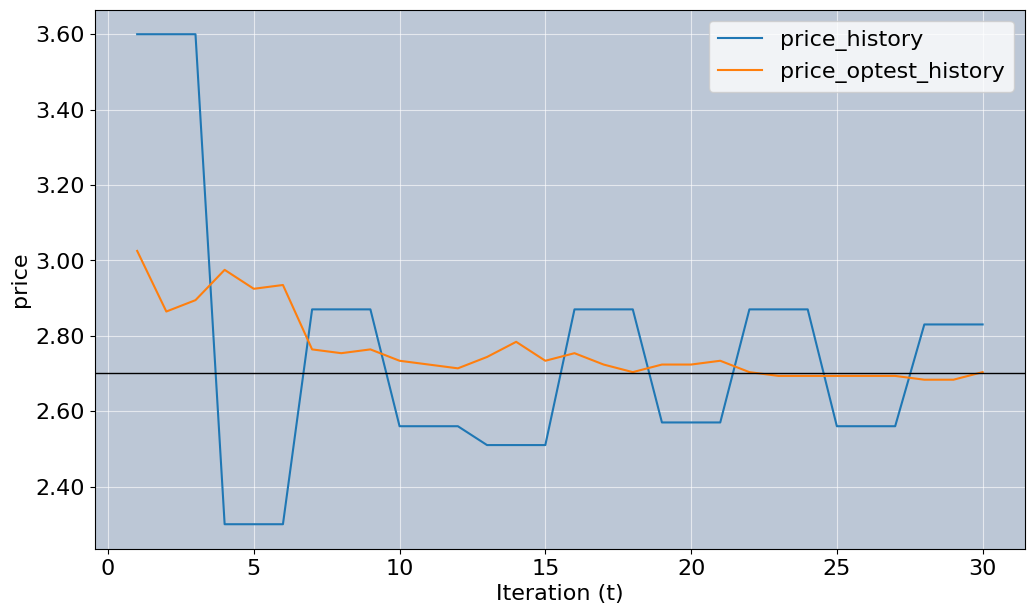

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))
bp.lineplot(
    _df_ts_summary, x ="n",
    y = ["price_history", "price_optest_history"], 
    y_axis_label='price',
    x_axis_label='Iteration (t)',
    h_line = p_opt,
    #y_lims = (2, 4.5),
    #x_lims = (1, 10),
    figsize=(12,6),
    ax = ax
    )

background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
ax.set_facecolor(background_color)
grid_color = "white"
grid_alpha = 0.6
ax.grid(True, color=grid_color, alpha=grid_alpha)

plt.show()

# Save

In [ ]:
#from datetime import date
from datetime import datetime
import json
import os
import arviz as az
from pathlib import Path


now = datetime.now()
date_iso_str = now.strftime("%Y%m%d%H%M")  # e.g. 202602220731
_save_sim_results = True # on by default

if _save_sim_results == True:
    print(f'example_case = {example_case}')
    now = datetime.now()
    date_iso_str = now.strftime("%Y%m%d%H%M")  # e.g. 202602220731
    file_name = f"ts_sim_results_{example_case}_{date_iso_str}.json"
    save_dir = "../data_sim_results"
    file_path = f'{save_dir}/{file_name}'
    traces_dir = Path(save_dir) / f"ts_traces_{example_case}_{date_iso_str}"
    traces_dir.mkdir(parents=True, exist_ok=True)
    
    print(f'file_path = {file_name}')
    print(f'traces_dir = {traces_dir}')

    # data to save
    data_sim_dict = {
        "example_case": example_case,
        "p1": p1,
        "a_true": a_true,
        "v_true": v_true,
        "CV_true": CV_true,
        "initial_prices": initial_prices,
        "K1": K1,
        "K2": K2,
        "Nk": Nk,
        "fix_sigma_log": fix_sigma_log,
        "a_fixed": a_fixed, 
        "m_a_linear_fixed": m_a_linear_fixed,
        "limit_max_price_change": limit_price_change,
        "max_price_change_1": max_price_change_1,
        "max_price_change_2": max_price_change_2,
        "sigma_log_true": sigma_log_true,
        "fixed_cost": fixed_cost,
        "variable_cost": variable_cost,
        "N_price_repeat" : N_price_repeat,
        "max_local_price_change_tf": max_local_price_change_tf,
        "price_anchor_1": price_anchor_1,
        "price_anchor_2": price_anchor_2,
        "local_deviation_1": repeat_deviation_1,
        "local_deviation_2": repeat_deviation_2,
        "hyperparameters": {
            "m_a": m_a,
            "sigma_a": sigma_a,
            "m_v": m_v,
            "sigma_v": sigma_v,
            "lower_v": lower_v,
            "sigma_log": sigma_log,
            "max_price_change": max_price_change,
            "min_price": price_min,
            "max_price": price_max
        },
        "df_ts_summary_str":_df_ts_summary.to_json(orient='records', date_format='iso'),
        "traces_dir": str(traces_dir),
        "n_traces": len(traces),
        "traces_format": "netcdf"
        }
    
    
    # Save parameters and dataframe
    #    - Open a file in write mode ('w') and save the dictionary as JSON
    with open(file_path, "w") as json_file:
        json.dump(data_sim_dict, json_file, indent=4)
        
    # Save traces seperately
        
    for t, idata in enumerate(traces, start=1):
        az.to_netcdf(idata, traces_dir / f"trace_t{t:03d}.nc")

else:
    print(f"_save_sim_results = {_save_sim_results}. Set _save_sim_results = True to save simulation results.")

example_case = case2
file_path = ts_sim_results_case2_202605271415.json
traces_dir = ../data_sim_results/ts_traces_case2_202605271415


What is Arviz?  
* Python library is an open-source package for the exploratory analysis of Bayesian models. It provides a unified, backend-agnostic interface for visualizing, diagnosing, and comparing the results of Bayesian inference, working with output from various probabilistic programming libraries (PPLs). 


NetCDF?
* Preserves posterior samples, coords, attrs
* Fast, compact, lossless
* Standard across PyMC / Stan / ArviZ
* Reloads instantly into InferenceData